## Wine Quality Prediction using Machine Learning

##  Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("All libraries imported successfully.")

All libraries imported successfully.


## Load the Dataset

In [4]:
df = pd.read_csv("/Users/sanjayduduka/WineQuality Pred/winequality (1).csv")      

print("Dataset Loaded Successfully!")

print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully!

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Exploratory Data Analysis

In [5]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nInformation")
df.info()

Shape : (1599, 12)

Columns
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Information
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual s

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


##  Check Missing Values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


## Identify Duplicate Records

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 240


## Remove Duplicate Records

In [9]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (1359, 12)


## Wine Quality Distribution

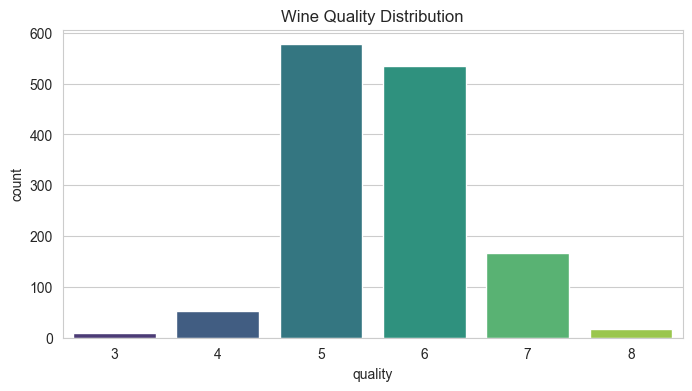

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="quality",
    palette="viridis"
)

plt.title("Wine Quality Distribution")
plt.show()

print(df["quality"].value_counts().sort_index())

## Convert Target Variable into Binary Classes

In [11]:

df["quality_label"] = (df["quality"] >= 7).astype(int)

df[["quality", "quality_label"]].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
5,5,0


## Class Distribution Analysis

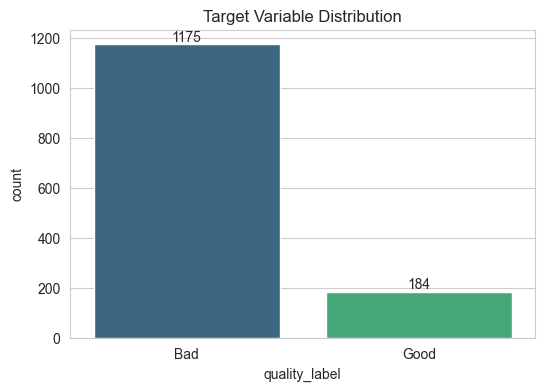

quality_label
0    1175
1     184
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="quality_label",
    palette="viridis"
)

plt.xticks([0,1],["Bad","Good"])

plt.title("Target Variable Distribution")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

print(df["quality_label"].value_counts())

## Feature and Target Separation

In [14]:

X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1359, 11)
Target Shape   : (1359,)


## Split Dataset into Training and Testing Sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1087, 11)
Testing Set  : (272, 11)


# Evaluate Logistic Regression without Scaling

In [19]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.875
Precision: 0.6153846153846154
Recall   : 0.21621621621621623
F1 Score : 0.32

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       235
           1       0.62      0.22      0.32        37

    accuracy                           0.88       272
   macro avg       0.75      0.60      0.63       272
weighted avg       0.85      0.88      0.85       272



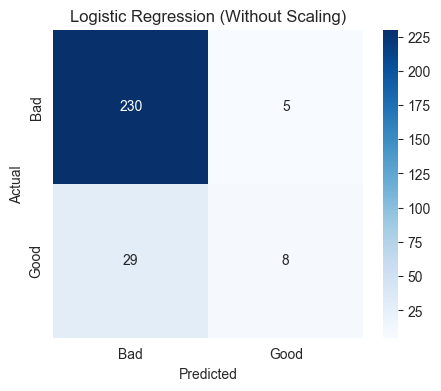

In [21]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression (Without Scaling)")

plt.show()

## Feature Scaling using StandardScaler

In [22]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Build Machine Learning Models

In [23]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

In [24]:
results = []

for name, model in models.items():

    if name == "Decision Tree":

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    else:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

## Model Performance Comparison

In [25]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.878676,0.576923,0.405405,0.476190
0,Logistic Regression,0.875000,0.600000,0.243243,0.346154
2,Decision Tree,0.830882,0.400000,0.486486,0.439024


## Model Accuracy Comparison

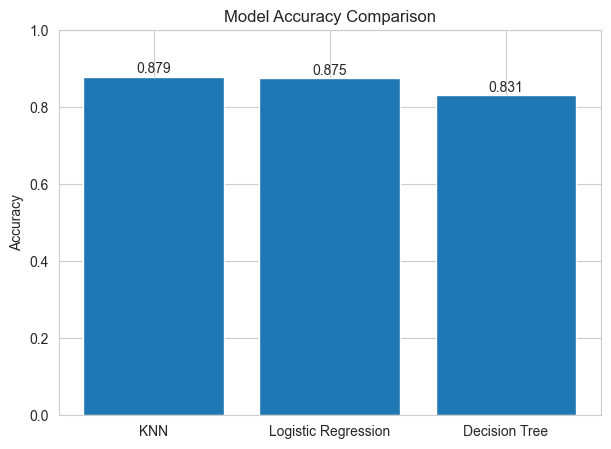

In [27]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.show()

## Hyperparameter Tuning using GridSearchCV

In [40]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    "n_neighbors": [7,9,11,13,15,17,19,21,23,25,27,31],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan","minkowski"],
    "p": [1,2]
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [7, 9, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

## Best Hyperparameters

In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}

Best Cross Validation Score:
0.46045140146996005


In [42]:
best_knn = grid_search.best_estimator_

best_knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [43]:
y_pred_best = best_knn.predict(X_test_scaled)
y_pred_best

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

## Evaluate the Optimized Model

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.8823529411764706
Precision: 0.5925925925925926
Recall   : 0.43243243243243246
F1 Score : 0.5

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       235
           1       0.59      0.43      0.50        37

    accuracy                           0.88       272
   macro avg       0.75      0.69      0.72       272
weighted avg       0.87      0.88      0.87       272



## Classification Report

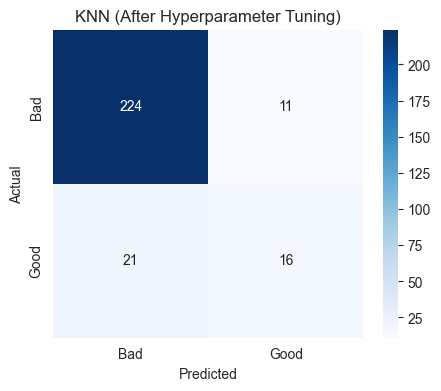

In [45]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad", "Good"],
    yticklabels=["Bad", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN (After Hyperparameter Tuning)")

plt.show()

## Comparision of  Train vs Test Evaluation

In [46]:
comparison = pd.DataFrame({
    "Model": ["KNN Before Tuning", "KNN After Tuning"],
    "Accuracy": [
        accuracy_score(y_test, models["KNN"].predict(X_test_scaled)),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, models["KNN"].predict(X_test_scaled)),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, models["KNN"].predict(X_test_scaled)),
        recall_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, models["KNN"].predict(X_test_scaled)),
        f1_score(y_test, y_pred_best)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN Before Tuning,0.878676,0.576923,0.405405,0.47619
1,KNN After Tuning,0.882353,0.592593,0.432432,0.50000


##  Feature Importance Analysis

In [47]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_knn,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1"
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
10,alcohol,0.255026
9,sulphates,0.127307
1,volatile acidity,0.103341
6,total sulfur dioxide,0.074661
3,residual sugar,0.065513
7,density,0.065479
2,citric acid,0.056370
0,fixed acidity,0.054523
5,free sulfur dioxide,0.048218
8,pH,-0.006396


##  Feature Importance Visualization

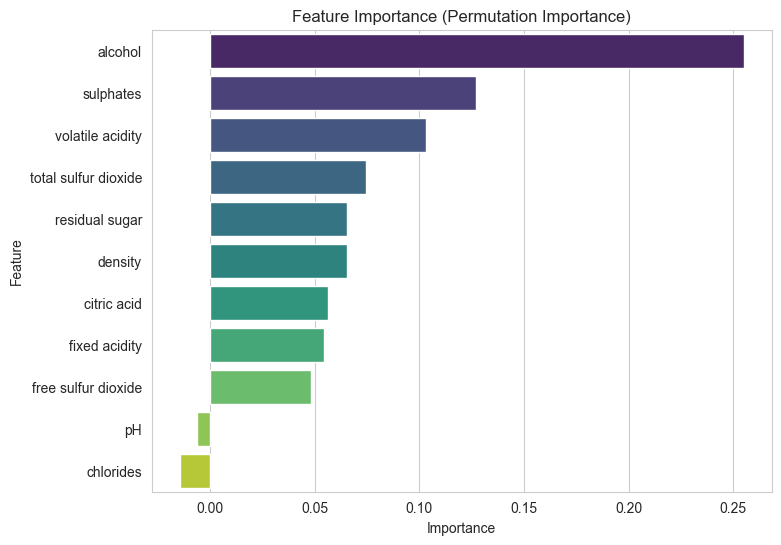

In [48]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance (Permutation Importance)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Save the Trained Model

In [ ]:
joblib.dump(best_knn, "wine_quality_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [ ]:
model = joblib.load("wine_quality_model.pkl")
scaler = joblib.load("scaler.pkl")

**Project Summary**

This project builds a binary classification model to predict wine quality using physicochemical properties. Wine samples with a quality score of **7 or above** are classified as **Good**, while the remaining samples are classified as **Bad**. The workflow includes data preprocessing, exploratory data analysis, duplicate removal, correlation analysis, feature scaling with **StandardScaler**, and model training. **Logistic Regression**, **K-Nearest Neighbors (KNN)**, and **Decision Tree** models were compared using Accuracy, Precision, Recall, and F1-Score. The best-performing model was optimized using **GridSearchCV**, analyzed with a learning curve, and interpreted using **Permutation Feature Importance**. Finally, the trained model and scaler were saved for future predictions.
